In [1]:
import sys
import os

# Add the desired directory to the sys.path
path_to_add = '/dtu-compute/msaca/muhrec_folder2/build-imagingsuite/Release/lib/'
sys.path.append(path_to_add)
path_to_add = '/dtu-compute/msaca/muhrec_folder2/amglib/CBCTCalibration/'
sys.path.append(path_to_add)
path_to_add = '/dtu-compute/msaca/muhrec_folder2/imagingsuite/package/'
sys.path.append(path_to_add)
path_to_add = '/zhome/71/c/146676/Desktop/msaca/main/'
sys.path.append(path_to_add)

In [3]:
import SimpleITK as sitk
import advfilters
from cil.io import TIFFStackReader
import imgalg
import numpy as np
import amglib.readers as io
import pymuhrec as pm
import matplotlib.pyplot as plt
from astropy.io import fits
import extended_data as ed
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer
import cor_tilt_corrector as ctc
import importlib
from cil.io import TIFFWriter, TIFFStackReader

In [3]:
importlib.reload(ed)

<module 'extended_data' from '/zhome/71/c/146676/Desktop/msaca/main/extended_data.py'>

In [4]:
skip = 1
slices = np.arange(40, 1616, skip)
path = '/work3/msaca/Mars_data_1/02_sinogramdata/sinograms/ABC_2/sinocleaned_#####.tif'

angles = None
N_pixels = 1698
N_slices = len(slices)
if angles is None:
    angles = np.linspace(0, 360, 1126, endpoint=True, dtype=np.float32)
    
ag = AcquisitionGeometry.create_Parallel3D(detector_position=[0,N_pixels//2,0])\
                            .set_angles(angles)\
                            .set_panel((N_pixels,N_slices), pixel_size=(1,1))\
                            .set_labels(labels=('vertical','angle','horizontal'))

sinograms = ed.ExtendedData()
sinograms.load_data(path = path, slices = slices)


In [5]:

sinograms.scale_data(scale=1/2500,offset=-12)
sinograms.pad_edges()
print(type(sinograms.data))

sinograms.acquisition_data(geometry=ag)
input_data = sinograms.data*100

<class 'numpy.ndarray'>


In [6]:
importlib.reload(ctc)

<module 'cor_tilt_corrector' from '/zhome/71/c/146676/Desktop/msaca/main/cor_tilt_corrector.py'>

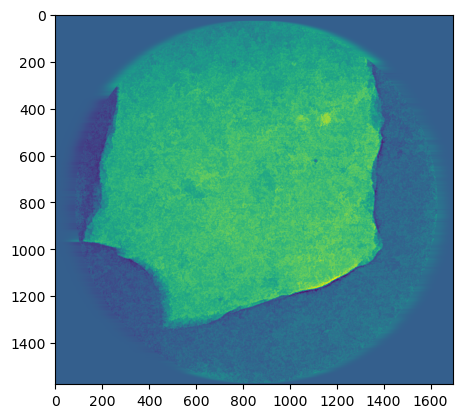

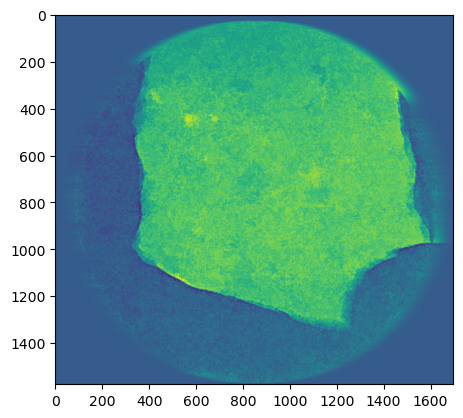

Iteration 0: Metric Value = -0.7558203465320282
The parameters are: 
  t  =  -4.52475051984154  pixels, 
alpha =  -0.031588335464271707  degrees
Iteration 30: Metric Value = -0.8498, Metric Difference = 0.0940
The parameters are: 
  t  =  -29.079526589523685  pixels, 
alpha =  -0.25164443175414714  degrees
Iteration 60: Metric Value = -0.8498, Metric Difference = 0.0000
The parameters are: 
  t  =  -29.08103637293232  pixels, 
alpha =  -0.2523399369795821  degrees
Iteration 90: Metric Value = -0.8498, Metric Difference = 0.0000
The parameters are: 
  t  =  -29.081117163117426  pixels, 
alpha =  -0.2523793411020067  degrees
Iteration 120: Metric Value = -0.8498, Metric Difference = 0.0000
The parameters are: 
  t  =  -29.081121590821482  pixels, 
alpha =  -0.2523814797624037  degrees
Iteration 150: Metric Value = -0.8498, Metric Difference = 0.0000
The parameters are: 
  t  =  -29.08112184181019  pixels, 
alpha =  -0.25238159505426816  degrees
Iteration 180: Metric Value = -0.8498, Metr

In [7]:
corrector = ctc.CTcorrector()
angles = np.linspace(0,360, num=1126)
corrector.set_angles(angles=angles)
corrector.load_data(input_data)
corrector.set_labels()
k_angle = 10
corrector.get_projection_and_opposite(k_angle)
corrector.register(learning_rate = 1, sampling_percentage = 0.1,
                     max_iter = 300,
                    metric_type = 'cor', optimizer_type = 'gd',
                     smoothing = 0,
                      shrinking = 1)
print(corrector.t, corrector.alpha)

In [77]:
from cil.plugins.astra import FBP

def show_slices(angle):
    angle_radians = np.deg2rad(angle)
    rotation_matrix = [
                    [np.cos(angle_radians), 0,  -np.sin(angle_radians)],
                    [0,                     1,                   0],
                    [np.sin(angle_radians), 0, np.cos(angle_radians)]
                ]
    matrix = [elem for row in rotation_matrix for elem in row]
    translation = [15, 0, 0]
    transform = corrector.transformation(matrix = matrix, translation = translation)
    data2 = corrector.resample(data=corrector.data, transform=transform)
    return data2
    skip = 200
    subslices = np.arange(40, 1616, skip)
    sinograms.set_data(data2)
    sinograms.acquisition_data(geometry=ag)
    sinograms.set_subdata(subslices=subslices)
    sinograms.remove_ring(subdata = True)


    reconstruction = np.empty((len(sinograms.subslices), sinograms.subdata.shape[2],sinograms.subdata.shape[2]))
    for i in range(len(sinograms.subslices)):
        data2D = sinograms.subdata.get_slice(vertical=i)
        data2D.reorder('astra')
        ag2D = data2D.geometry
        ag2D.set_angles(ag2D.angles, initial_angle=0.0)
        ig2D = ag2D.get_ImageGeometry()
        device = 'gpu'
        fbp = FBP(ig2D,ag2D,device)
        print(type(data2D))
        reconstruction[i] = fbp(data2D).as_array()
        print(i)
        #plt.figure(figsize=(10,10))
        #plt.imshow(reconstruction[i])
        #plt.clim([-0.1,0.1])
        #plt.show()


In [79]:
data2 = show_slices(0.325)

In [81]:
skip = 1
subslices = np.arange(40, 1616, skip)
sinograms.set_data(data2)
sinograms.acquisition_data(geometry=ag)
sinograms.set_subdata(subslices=subslices)
sinograms.remove_ring(subdata = False)
recon = sinograms.fbp(subdata = False)


Finish Ring Remover


NameError: name 'cil' is not defined

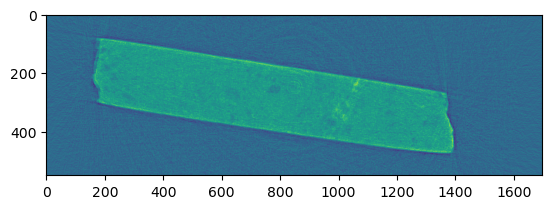

In [89]:
recon_array = recon.as_array()[:,600:1150,:]
plt.imshow(recon_array[600])

In [ ]:
path = '/dtu-compute/msaca/sliceA_neutron_psi/My_reconstruction/CoR_corrected/'
#writer = TIFFWriter(data=recon, file_name=path, counter_offset=0, compression='uint16')

In [ ]:
#writer.write()

In [5]:
reader = TIFFStackReader('/dtu-compute/msaca/sliceA_neutron_psi/My_reconstruction/')
data = reader.read()

In [29]:
data_sliced = data[:1400,600:1150,100:-200]
nx, ny, nz = np.shape(data_sliced)
ig = ImageGeometry(voxel_num_x=nz, voxel_num_y=ny, voxel_num_z=nx)
data_sliced = ImageData(array = data_sliced, geometry=ig)
path = '/dtu-compute/msaca/sliceA_neutron_psi/My_reconstructions/CoR_corrected_and_croppedFBP'
writer = TIFFWriter(data=data_sliced, file_name=path, counter_offset=0, compression='uint16')
writer.write()
#from cil.processors import Slicer
#roi = {'horizontal':(10,-10,1)}
#processor = Slicer(roi)
#processor.set_input(data)
#data_sliced= processor.get_output()